In [1]:
import sys
sys.path.append('/u/aurora-r0/govorcin/01_OPERA/DSWx_SWOT/dswx-swot/src')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import dswx_swot.database_utils
import dswx_swot.download
import ast
import numpy as np
from pathlib import Path
import xarray as xr
import rioxarray
import pandas as pd
from matplotlib import pyplot as plt

/u/aurora-r0/govorcin/miniconda/miniforge/envs/dswx-swot/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# load MGRS database
mgrs_database = dswx_swot.database_utils.read_database('notebooks/database/MGRS_tile_swot_coast.sqlite')

In [5]:
# work on MGRS tile 11SLT
mgrs_tile_id = '11SLT'

# find SWOT id
swot_ids = ast.literal_eval(mgrs_database[mgrs_database.mgrs_tile == mgrs_tile_id].swot_id.values[0])
split_ids = np.array([item.split('_') for item in swot_ids])
unique_tracks = np.unique(split_ids[:, 0])
print(f'Unique SWOT tracks {unique_tracks}')

# Find track and frame id
indices_for_value = np.where(split_ids[:, 0] == '539')[0]
track_id = np.array(swot_ids)[indices_for_value]
track_id

Unique SWOT tracks ['233' '246' '261' '274' '539' '552']


array(['539_107F', '539_108F'], dtype='<U8')

In [6]:
output_directory = Path('/u/aurora-r0/govorcin/01_OPERA/DSWx_SWOT/notebooks/data/calval')
result  = dswx_swot.download.download_swot(output_directory / "LA",
                                    '2025-04-01T00:00:00',
                                    '2025-05-01T00:00:00', '539_107F')

swot_dates = list(map(lambda x: x.split('/')[-1].split('_')[13], result))
print(f'Downloaded dates: {swot_dates}')

Login in to earthdata with: netcdf
Authentication success!


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 676.39it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 11715.93it/s]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 26379.27it/s]

Downloaded dates: ['20250405T131511']


In [7]:
mgrs_tile_df = mgrs_database[mgrs_database.mgrs_tile == mgrs_tile_id]
tile_grid = dswx_swot.database_utils.get_mgrs_tile_coords(mgrs_tile_df)

# Read SWOT and interpolate to grid

In [8]:
# Read the 20240415
ds = xr.open_dataset(result[0], chunks={})
ds = ds.rio.write_crs(ds.crs.attrs['crs_wkt'],
    inplace=False
)
swot_time = pd.to_datetime(ds.attrs['time_granule_start'])

/u/aurora-r0/govorcin/miniconda/miniforge/envs/dswx-swot/lib/python3.13/site-packages/dask/_task_spec.py:755: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)


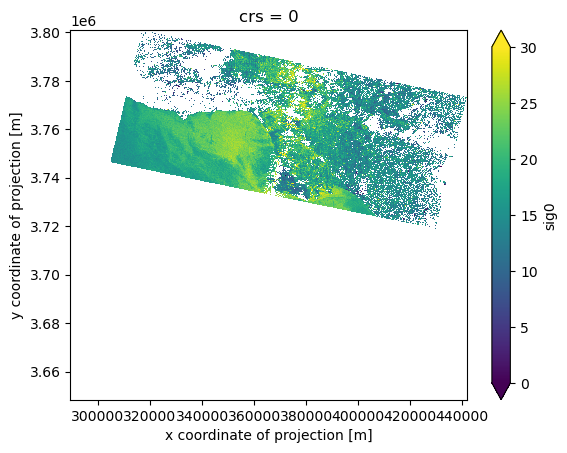

In [9]:
(10 * np.log10(ds.sig0)).plot.imshow(vmin=-0, vmax=30)

In [10]:
# Interpolate to grid
ds1_reprojected = ds[["water_frac", "water_frac_uncert", "inc", "sig0"]].rio.reproject(f"EPSG:{tile_grid.epsg}")
interpolated = ds1_reprojected.interp(x=tile_grid.x, y=tile_grid.y)

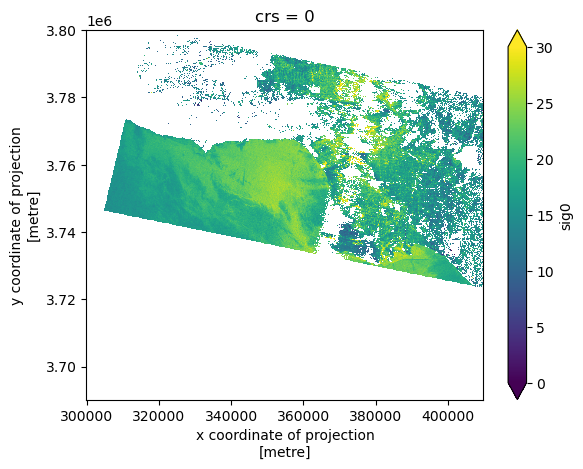

In [11]:
(10 * np.log10(interpolated.sig0)).plot.imshow(vmin=-0, vmax=30)

In [12]:
# Download ASF HAND
hand_input = dswx_swot.download.download_stac(output_directory / "LA",
                                              aoi_bbox=mgrs_tile_df.buffer(0.1).iloc[0].bounds,
                                              stac_lyr='hand')

/tmp/ipykernel_82158/3107261414.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  aoi_bbox=mgrs_tile_df.buffer(0.1).iloc[0].bounds,


Download URL: https://glo-30-hand.s3.us-west-2.amazonaws.com/v1/2021/Copernicus_DSM_COG_10_N34_00_W120_00_HAND.tif
Saving to: /u/aurora-r0/govorcin/01_OPERA/DSWx_SWOT/notebooks/data/calval/LA/temp/Copernicus_DSM_COG_10_N34_00_W120_00_HAND.tif
Download URL: https://glo-30-hand.s3.us-west-2.amazonaws.com/v1/2021/Copernicus_DSM_COG_10_N34_00_W119_00_HAND.tif
Saving to: /u/aurora-r0/govorcin/01_OPERA/DSWx_SWOT/notebooks/data/calval/LA/temp/Copernicus_DSM_COG_10_N34_00_W119_00_HAND.tif
Download URL: https://glo-30-hand.s3.us-west-2.amazonaws.com/v1/2021/Copernicus_DSM_COG_10_N34_00_W118_00_HAND.tif
Saving to: /u/aurora-r0/govorcin/01_OPERA/DSWx_SWOT/notebooks/data/calval/LA/temp/Copernicus_DSM_COG_10_N34_00_W118_00_HAND.tif
Download URL: https://glo-30-hand.s3.us-west-2.amazonaws.com/v1/2021/Copernicus_DSM_COG_10_N33_00_W120_00_HAND.tif
Saving to: /u/aurora-r0/govorcin/01_OPERA/DSWx_SWOT/notebooks/data/calval/LA/temp/Copernicus_DSM_COG_10_N33_00_W120_00_HAND.tif
Download URL: https://glo-30

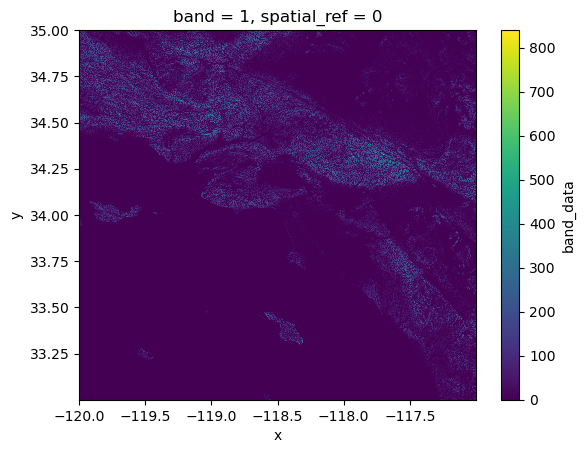

In [13]:
hand_xr = xr.open_dataset(hand_input)
hand_xr.band_data.isel(band=0).plot.imshow()

In [14]:
hand_xr_mgrs = hand_xr[["band_data"]].rio.reproject(f"EPSG:{tile_grid.epsg}")
hand_xr_mgrs_interp = hand_xr_mgrs.interp(x=tile_grid.x, y=tile_grid.y)

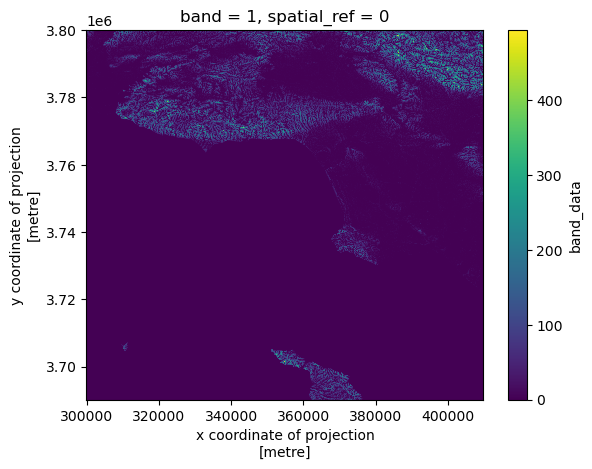

In [15]:
hand_xr_mgrs_interp.band_data.isel(band=0).plot.imshow()

In [16]:
mask1 = (interpolated.water_frac>0.6) & (interpolated.water_frac<100) & (interpolated.water_frac_uncert <1)
mask2 = mask1 & (hand_xr_mgrs_interp.band_data.isel(band=0) < 10)

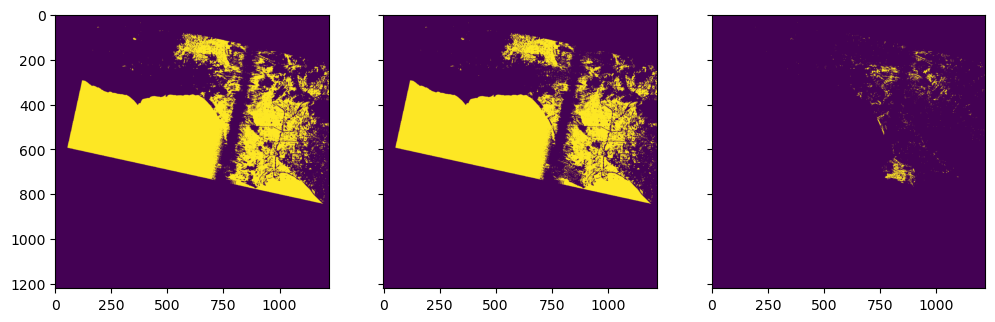

In [17]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,6))
ax[0].imshow(np.flipud(mask1))
ax[1].imshow(np.flipud(mask2))
ax[2].imshow(np.flipud(mask1 ^ mask2))

Text(0.5, 1.0, 'Diff')

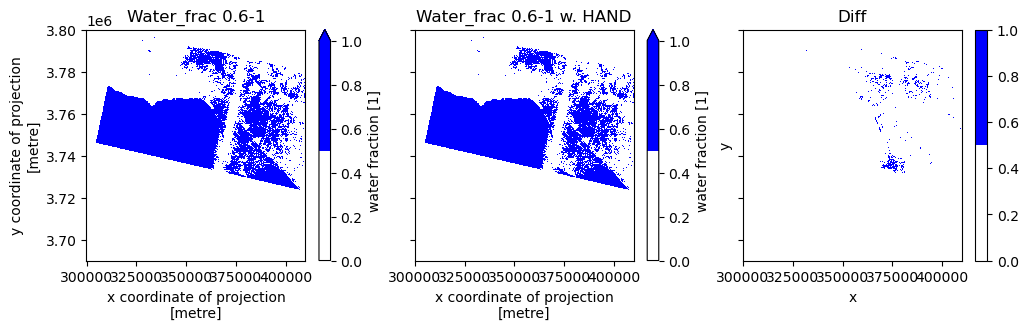

In [18]:
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

# Create a discrete colormap with 2 values: 0 and 1
cmap = ListedColormap(['white', 'blue'])
kwargs = dict(vmin=0, vmax=1, cmap=cmap)
fig, ax = plt.subplots(1,3, figsize=(12,3), sharey=True)
interpolated.water_frac.where(mask1).plot.imshow(ax=ax[0], **kwargs)
interpolated.water_frac.where(mask2).plot.imshow(ax=ax[1], **kwargs)
xr.DataArray(mask1^mask2, dims=('y','x'),
             coords={'x':tile_grid.x,
                     'y':tile_grid.y}).plot.imshow(ax=ax[2], **kwargs)
ax[1].set_ylabel('')
ax[0].set_title('Water_frac 0.6-1')
ax[1].set_title('Water_frac 0.6-1 w. HAND')
ax[2].set_title('Diff')

# Download land-cover

In [60]:
worldcover = dswx_swot.download.download_stac(output_directory / "LA",
                                              aoi_bbox=mgrs_tile_df.buffer(0.1).iloc[0].bounds,
                                              stac_lyr='esa_worldcover')

/tmp/ipykernel_82158/1134488181.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  aoi_bbox=mgrs_tile_df.buffer(0.1).iloc[0].bounds,


Download URL: s3://esa-worldcover/v200/2021/map/ESA_WorldCover_10m_2021_v200_N33W120_Map.tif
Saving to: /u/aurora-r0/govorcin/01_OPERA/DSWx_SWOT/notebooks/data/calval/LA/temp/urn:eop:VITO:ESA_WorldCover_10m_2021_AWS_V2:ESA_WorldCover_10m_2021_v200_N33W120.tif


In [ ]:
worldcover_xr = xr.open_dataset(worldcover, chunks={})
worldcover_mgrs = worldcover_xr[["band_data"]].rio.reproject(f"EPSG:{tile_grid.epsg}")
worldcover_mgrs_interp = worldcover_mgrs.interp(x=tile_grid.x, y=tile_grid.y)

worldcover_mgrs_interp = worldcover_mgrs_interp.interpolate_na(dim="y", method="nearest",
                                                               fill_value="extrapolate")
worldcover_mgrs_interp = worldcover_mgrs_interp.interpolate_na(dim="x", method="nearest",
                                                               fill_value="extrapolate")

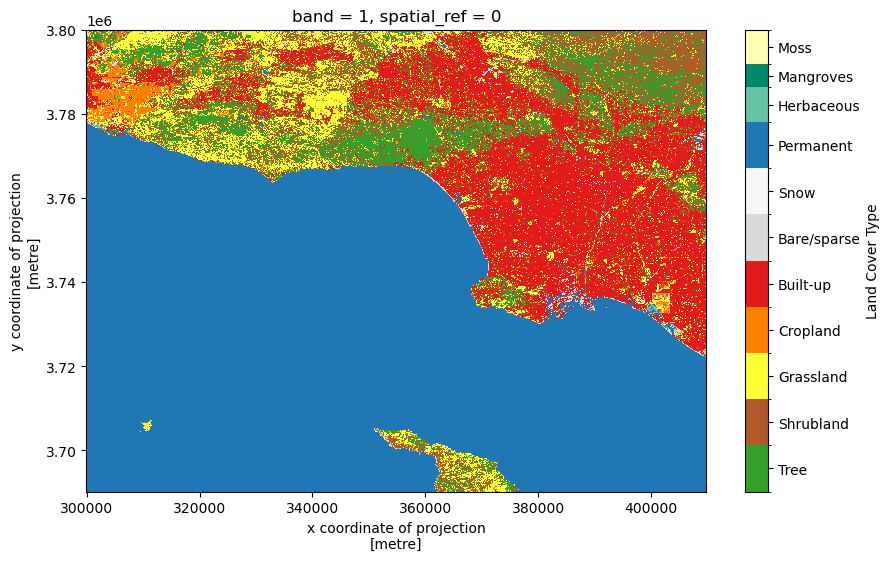

In [77]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib as mpl
# Example classes and labels
classes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
labels = ['Tree', 'Shrubland', 'Grassland', 'Cropland', 'Built-up', 
          'Bare/sparse', 'Snow', 'Permanent', 'Herbaceous', 'Mangroves', 'Moss']
# HEX colors from the legend in the image
hex_colors = ['#33a02c', '#b15928', '#ffff33', '#ff7f00', '#e31a1c',
              '#d9d9d9', '#f7f7f7', '#1f78b4', '#66c2a5', '#00896b', '#ffffb2']

# Create colormap and norm
rgb_colors = [mpl.colors.to_rgb(c) for c in hex_colors]
cmap = ListedColormap(rgb_colors)

# Set boundaries so that each class is centered properly
boundaries = [5] + [(classes[i] + classes[i + 1]) / 2
                    for i in range(len(classes) - 1)] + [105]
tick_positions = [(boundaries[i] + boundaries[i+1]) / 2
                  for i in range(len(boundaries) - 1)]

norm = BoundaryNorm(boundaries, len(classes))

fig, ax = plt.subplots(figsize=(10, 6))
im = worldcover_mgrs_interp.band_data.isel(band=0).plot.imshow(cmap=cmap,
                                                  norm=norm,
                                                  add_colorbar=False,
                                                  ax=ax)

# Add custom colorbar
cbar = fig.colorbar(im, ax=ax, boundaries=boundaries,
                    ticks=tick_positions, spacing='proportional')
cbar.ax.set_yticklabels(labels)
cbar.set_label('Land Cover Type')

# Z-shaped membership function (ZMF)

In [87]:
def zmf_xr(da, minv, maxv):
    minv = xr.full_like(da, minv) if np.isscalar(minv) else minv
    maxv = xr.full_like(da, maxv) if np.isscalar(maxv) else maxv

    mid = (minv + maxv) / 2
    scale = maxv - minv + 1e-10  # avoid divide by zero

    z = xr.full_like(da, 1.0, dtype=np.float32)

    mask_left = (da >= minv) & (da <= mid)
    mask_right = (da > mid) & (da <= maxv)

    z = z.where(~mask_left, 1 - 2 * ((da - minv) / scale) ** 2)
    z = z.where(~mask_right, 2 * ((da - maxv) / scale) ** 2)

    z = z.where(da < maxv, 0.0)
    z = z.where(da > minv, 1.0)
    z = z.where(~xr.ufuncs.isnan(da), np.nan)  # optional if NaNs should stay NaN

    return z

def smf_xr(da, minv, maxv):
    minv = xr.full_like(da, minv) if np.isscalar(minv) else minv
    maxv = xr.full_like(da, maxv) if np.isscalar(maxv) else maxv

    mid = (minv + maxv) / 2
    scale = maxv - minv + 1e-10

    s = xr.full_like(da, 0.0, dtype=np.float32)

    s = s.where(da <= minv, 0.0)
    s = s.where(da >= maxv, 1.0)
    s = s.where((da <= minv) | (da >= maxv), s)

    left = (da > minv) & (da <= mid)
    right = (da > mid) & (da < maxv)

    s = s.where(~left, 2 * ((da - minv) / scale)**2)
    s = s.where(~right, 1 - 2 * ((da - maxv) / scale)**2)

    s = s.where(~xr.ufuncs.isnan(da), np.nan)

    return s

: 

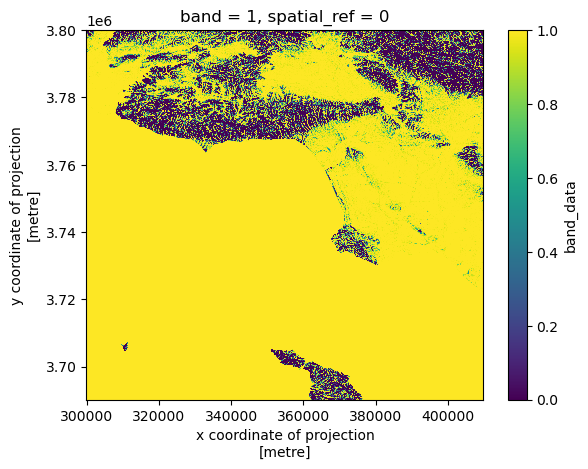

In [85]:
zmf_xr(hand_xr_mgrs_interp, 0, 50).band_data.isel(band=0).plot.imshow()